# 01 - Data Audit Oxford Flowers 102

Muc tieu:
- Kiem tra split train/valid/test
- Kiem tra class balance
- Kiem tra image integrity va leakage
- **Visualize du lieu**

In [1]:
from collections import Counter
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import hashlib
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path('/home/nguyenhuynh/Documents/deep-learning/dataset/flower_data')
SPLITS = ['train', 'valid', 'test']
assert DATA_DIR.exists(), f'Missing dataset dir: {DATA_DIR.resolve()}'

# Load ten hoa
with (DATA_DIR / 'cat_to_name.json').open('r', encoding='utf-8') as f:
    cat_to_name = json.load(f)

print('Dataset:', DATA_DIR.resolve())
print('So loai hoa:', len(cat_to_name))

Dataset: /home/nguyenhuynh/Documents/deep-learning/dataset/flower_data
So loai hoa: 102


In [2]:
def list_images(split):
    return sorted((DATA_DIR / split).rglob('*.jpg'))

summary = []
for split in SPLITS:
    files = list_images(split)
    classes = {p.parent.name for p in files}
    summary.append({
        'split': split,
        'num_images': len(files),
        'num_classes': len(classes),
    })

summary_df = pd.DataFrame(summary)
summary_df

,split,num_images,num_classes
0,train,6552,102
1,valid,800,100
2,test,819,102


## Visualize: Số lượng ảnh mỗi split

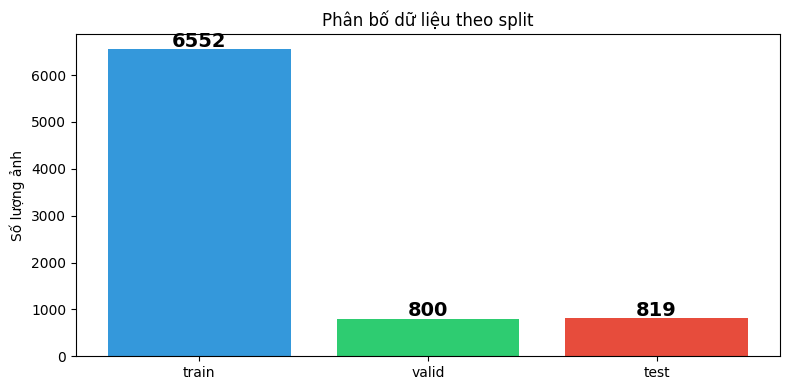

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.bar(summary_df['split'], summary_df['num_images'], color=colors)
for bar, val in zip(bars, summary_df['num_images']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(val),
            ha='center', fontweight='bold', fontsize=14)
ax.set_ylabel('Số lượng ảnh')
ax.set_title('Phân bố dữ liệu theo split')
plt.tight_layout()
plt.show()

## Visualize: Ảnh mẫu từ 10 loại hoa ngẫu nhiên

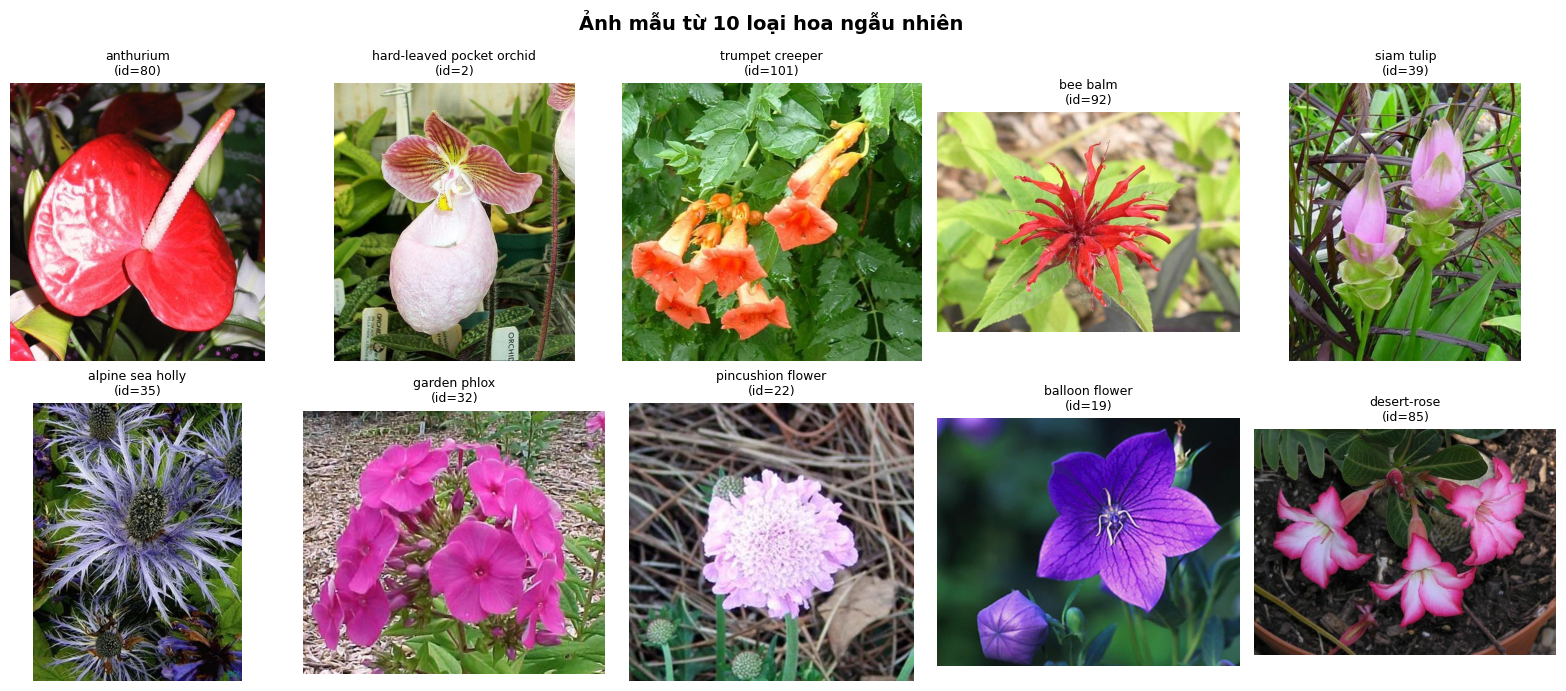

In [4]:
# Hiển thị 2 ảnh mẫu từ 10 loại hoa ngẫu nhiên
random.seed(42)
class_dirs = sorted((DATA_DIR / 'train').iterdir())
sample_classes = random.sample(class_dirs, min(10, len(class_dirs)))

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, cls_dir in zip(axes.flat, sample_classes):
    cls_id = cls_dir.name
    cls_name = cat_to_name.get(cls_id, f'class {cls_id}')
    imgs = sorted(cls_dir.glob('*.jpg'))
    if imgs:
        img = Image.open(imgs[0]).convert('RGB')
        ax.imshow(img)
    ax.set_title(f'{cls_name}\n(id={cls_id})', fontsize=9)
    ax.axis('off')

plt.suptitle('Ảnh mẫu từ 10 loại hoa ngẫu nhiên', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/reports/sample_flowers.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualize: Phân bố số lượng ảnh theo class (class balance)

min/max class count: 27 206
mean/std class count: 64.24 35.4


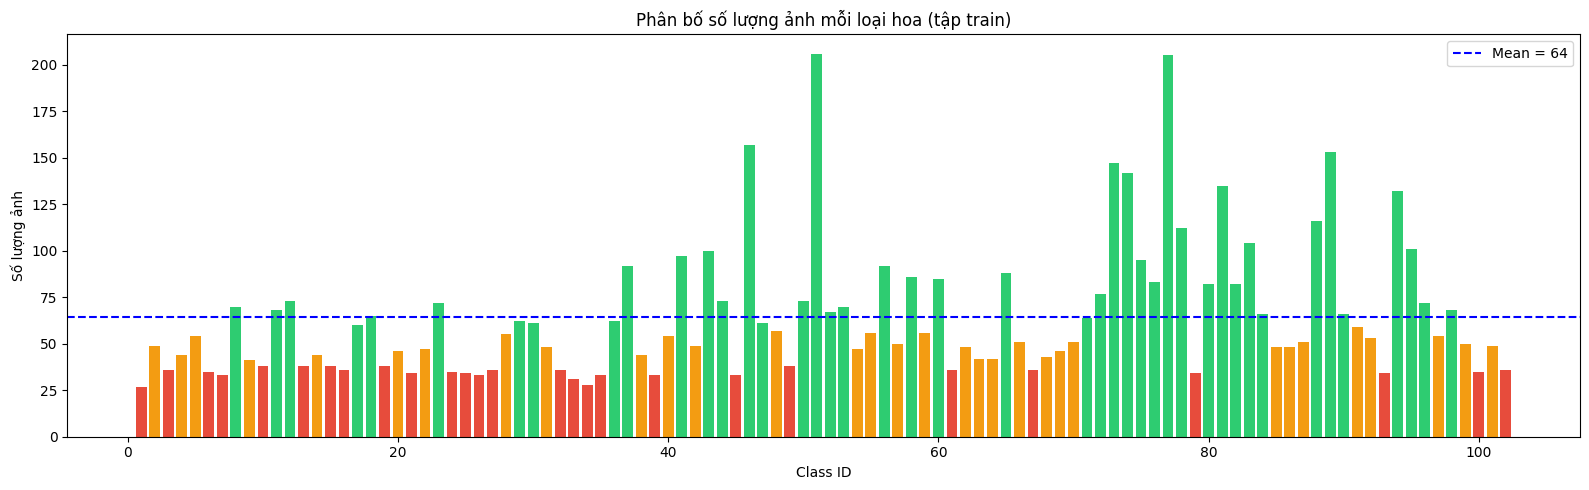

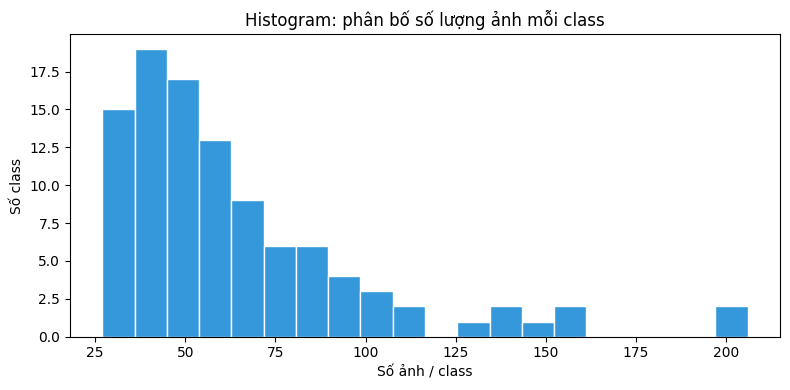

In [5]:
train_files = list_images('train')
train_counts = Counter([p.parent.name for p in train_files])
count_df = pd.DataFrame({'class_id': list(train_counts.keys()), 'count': list(train_counts.values())})
count_df['class_id'] = count_df['class_id'].astype(int)
count_df = count_df.sort_values('class_id').reset_index(drop=True)
print('min/max class count:', count_df['count'].min(), count_df['count'].max())
print('mean/std class count:', round(count_df['count'].mean(), 2), round(count_df['count'].std(), 2))

# Bar chart phân bố class
fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#e74c3c' if c < 40 else '#f39c12' if c < 60 else '#2ecc71' for c in count_df['count']]
ax.bar(count_df['class_id'], count_df['count'], color=colors, width=0.8)
ax.axhline(y=count_df['count'].mean(), color='blue', linestyle='--', label=f'Mean = {count_df["count"].mean():.0f}')
ax.set_xlabel('Class ID')
ax.set_ylabel('Số lượng ảnh')
ax.set_title('Phân bố số lượng ảnh mỗi loại hoa (tập train)')
ax.legend()
plt.tight_layout()
plt.savefig('/home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/reports/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(count_df['count'], bins=20, color='#3498db', edgecolor='white')
ax.set_xlabel('Số ảnh / class')
ax.set_ylabel('Số class')
ax.set_title('Histogram: phân bố số lượng ảnh mỗi class')
plt.tight_layout()
plt.show()

## Visualize: Kích thước ảnh gốc

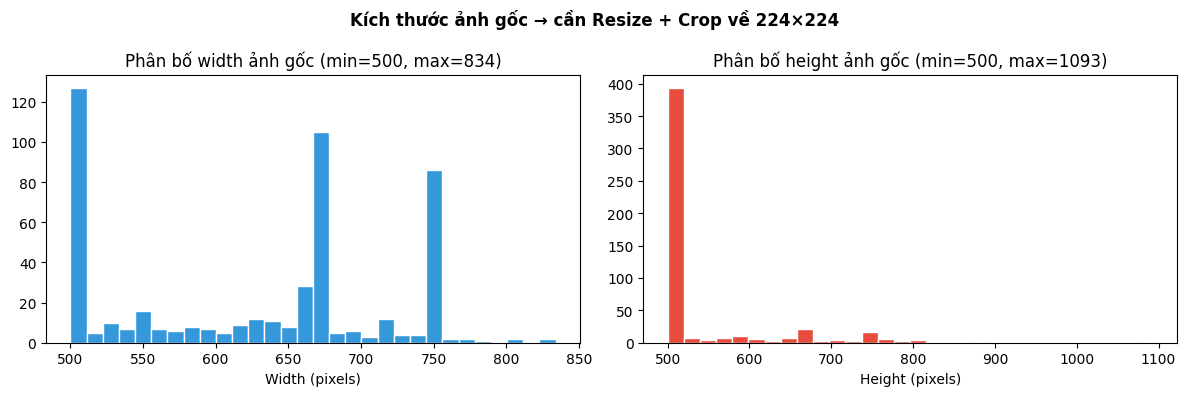

Width:  min=500, max=834, mean=626
Height: min=500, max=1093, mean=536


In [6]:
# Kiểm tra kích thước ảnh gốc (sample 500 ảnh)
random.seed(42)
sample_files = random.sample(train_files, min(500, len(train_files)))
widths, heights = [], []
for fp in sample_files:
    with Image.open(fp) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_title(f'Phân bố width ảnh gốc (min={min(widths)}, max={max(widths)})')
axes[1].hist(heights, bins=30, color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_title(f'Phân bố height ảnh gốc (min={min(heights)}, max={max(heights)})')
plt.suptitle('Kích thước ảnh gốc → cần Resize + Crop về 224×224', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Width:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}')
print(f'Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}')

## Visualize: Augmentation trước/sau

In [7]:
import os

print(os.listdir("/home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/src"))
print(os.listdir("/home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/src/flowers102"))

['flowers102']
['models.py', 'data.py', 'experiment.py', '__pycache__', 'utils.py', '__init__.py', 'train.py', 'evaluate.py']


/home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/src


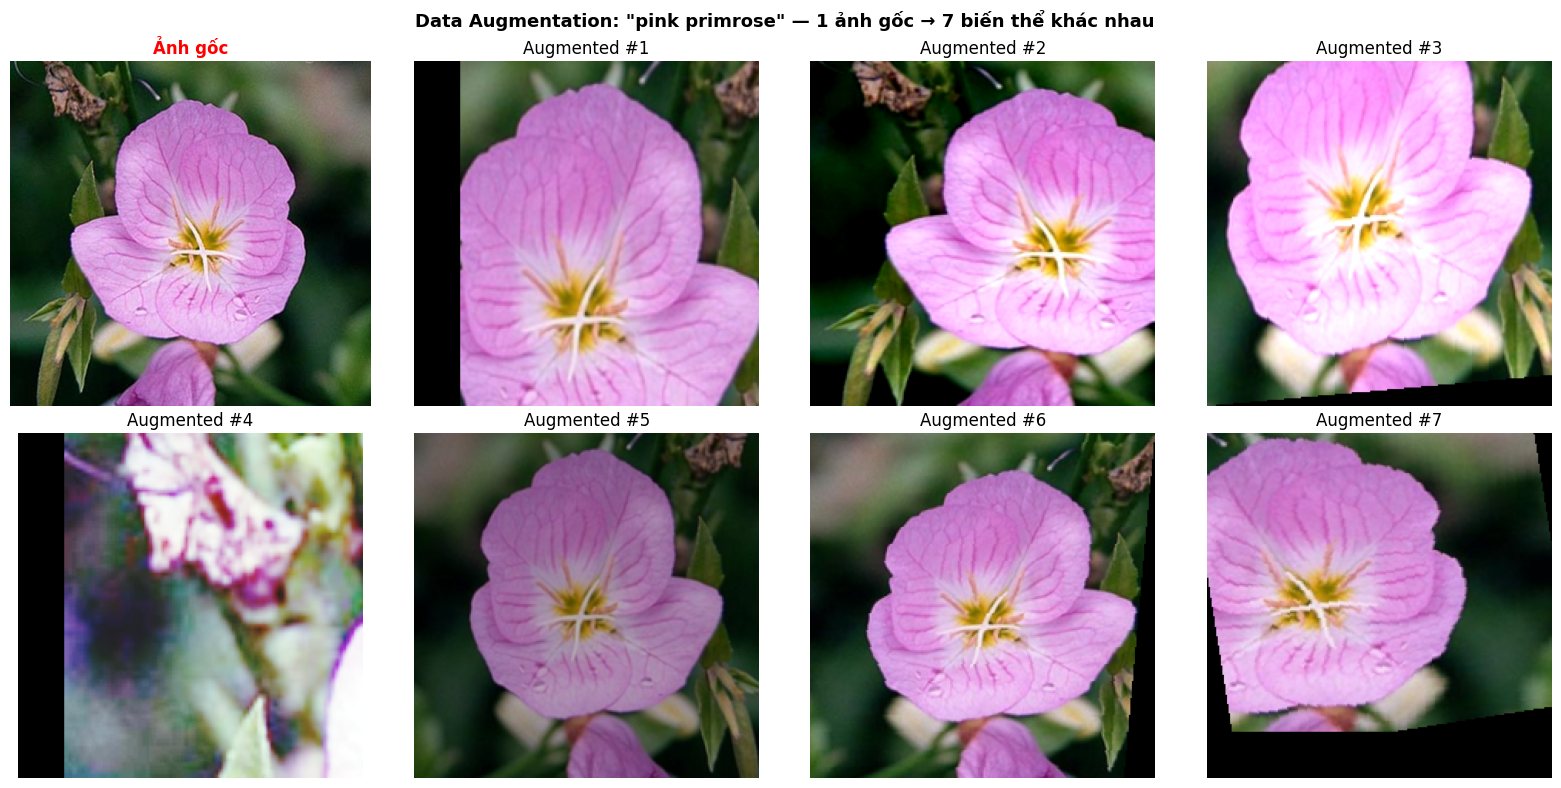

In [11]:
from pathlib import Path
import sys

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src"))

print(sys.path[0])  # debug

from flowers102.data import build_transforms, IMAGENET_MEAN, IMAGENET_STD

train_tf, eval_tf = build_transforms(
    image_size=224, use_augmentation=True,
    randaugment=True, randaugment_num_ops=2, randaugment_magnitude=9,
)

def denormalize(tensor):
    """Chuyển tensor normalized về ảnh hiển thị được."""
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    img = tensor.permute(1, 2, 0).numpy()
    img = img * std + mean
    return np.clip(img, 0, 1)

# Chọn 1 ảnh mẫu
sample_img_path = sorted((DATA_DIR / 'train' / '1').glob('*.jpg'))[0]
original = Image.open(sample_img_path).convert('RGB')
cls_name = cat_to_name.get('1', 'class 1')

# Tạo 7 augmented versions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(original)
axes[0, 0].set_title('Ảnh gốc', fontweight='bold', color='red')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flat[1:]):
    augmented = train_tf(original)
    ax.imshow(denormalize(augmented))
    ax.set_title(f'Augmented #{i+1}')
    ax.axis('off')

plt.suptitle(f'Data Augmentation: "{cls_name}" — 1 ảnh gốc → 7 biến thể khác nhau',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/reports/augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## Kiểm tra data integrity & leakage

In [12]:
def check_corrupted(files):
    bad = []
    for fp in files:
        try:
            with Image.open(fp) as im:
                im.verify()
        except (UnidentifiedImageError, OSError, ValueError):
            bad.append(str(fp))
    return bad

def md5_file(path):
    h = hashlib.md5()
    with path.open('rb') as f:
        while True:
            chunk = f.read(8192)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

split_hashes = {}
integrity_rows = []
for split in SPLITS:
    files = list_images(split)
    bad = check_corrupted(files)
    split_hashes[split] = {md5_file(p): str(p) for p in files}
    integrity_rows.append({'split': split, 'corrupted': len(bad)})

leak_train_valid = len(set(split_hashes['train']).intersection(split_hashes['valid']))
leak_train_test = len(set(split_hashes['train']).intersection(split_hashes['test']))
leak_valid_test = len(set(split_hashes['valid']).intersection(split_hashes['test']))

print('duplicate train-valid:', leak_train_valid)
print('duplicate train-test :', leak_train_test)
print('duplicate valid-test :', leak_valid_test)
pd.DataFrame(integrity_rows)

duplicate train-valid: 1
duplicate train-test : 0
duplicate valid-test : 0


,split,corrupted
0,train,0
1,valid,0
2,test,0


In [13]:
report = {
    'summary': summary,
    'class_balance': {
        'min': int(count_df['count'].min()),
        'max': int(count_df['count'].max()),
        'mean': float(count_df['count'].mean()),
        'std': float(count_df['count'].std()),
    },
    'leakage': {
        'train_valid': leak_train_valid,
        'train_test': leak_train_test,
        'valid_test': leak_valid_test,
    }
}

out = Path('/home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/reports/data_audit_report.json')
out.parent.mkdir(parents=True, exist_ok=True)
with out.open('w', encoding='utf-8') as f:
    json.dump(report, f, indent=2)
print('saved:', out.resolve())

saved: /home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/reports/data_audit_report.json
